# SITCOMTN-092 - Update single slew analysis to use total Forces and Moments

13 Nov 2024

Laura Toribio San Cipriano

**Description**

Right now, the single slew analysis notebook shows plots with the applied forces for each hard point actuator. We want a more complete and summarized analysis. For that, we can either replace the current plots or add new plots containing the total Forces and Moments during a slew. 

Ensure that we include the breakaway limits in the plots to know how far we are from the limits. Maybe we should keep existing plots with the breakaway, but we might need to find how the breakaway limits reflect in Forces/Moments. 

[Ticket SITCOM-1114](https://rubinobs.atlassian.net/browse/SITCOM-1114)

To develop this ticket we are going to follow the previous ticket: *[SITCOMTN-092] - M1M3 Inertia Compensation Performance with Hard Points Forces*

*Pending task*: Include the breakaway limits in the plots

## Notebook Preparation

In [1]:
%matplotlib inline
%load_ext lab_black
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.time import Time
from pathlib import Path
from datetime import timedelta
import numpy as np


import awkward as ak
import awkward_pandas as akpd

from operator import attrgetter
from astropy import units as u

from lsst.summit.utils.m1m3 import inertia_compensation_system as m1m3_ics
from lsst.summit.utils.m1m3.plots import inertia_compensation_system as m1m3_ics_plots
from lsst.summit.utils.blockUtils import BlockParser
from lsst.summit.utils.efdUtils import makeEfdClient, getEfdData, EfdClient
from lsst.summit.utils.tmaUtils import (
    getCommandsDuringEvent,
    TMAEvent,
    TMAEventMaker,
    TMAState,
)
from lsst.summit.utils.utils import setupLogging
from lsst.sitcom.vandv.logger import create_logger

import matplotlib.dates as mdates

setupLogging()

## Create Event Maker

We want to create a single instance of the `TMAEventMaker` object.  
Each instance might be quite heavy. 

In [3]:
plot_path = Path("./plots")
plot_path.mkdir(exist_ok=True, parents=True)

log = create_logger("m1m3_ics_slew")
log.setLevel("DEBUG")
log.propagate = True

event_maker = TMAEventMaker()
efd_client = makeEfdClient()

## Helper functions

In [4]:
class M1M3ICSAnalysis:
    """
    Evaluate the M1M3 Inertia Compensation System's performance by
    calculating the minima, maxima and peak-to-peak values during a
    slew. In addition, calculates the mean, median and standard deviation
    when the slew has contant velocity or zero acceleration.

    Parameters
    ----------
    event : `lsst.summit.utils.tmaUtils.TMAEvent`
        Abtract representation of a slew event.
    efd_client : EfdClient
        Client to access the EFD.
    inner_pad : float, optional
        Time padding inside the stable time window of the slew.
    outer_pad : float, optional
        Time padding outside the slew time window.
    n_sigma : float, optional
        Number of standard deviations to use for the stable region.
    log : logging.Logger, optional
        Logger object to use for logging messages.
    """

    def __init__(
        self,
        event: TMAEvent,
        efd_client: EfdClient,
        inner_pad: float = 1.0,
        outer_pad: float = 1.0,
        n_sigma: float = 1.0,
        log: logging.Logger | None = None,
    ):
        self.log = (
            log.getChild(type(self).__name__)
            if log is not None
            else logging.getLogger(type(self).__name__)
        )

        self.event = event
        self.inner_pad = inner_pad * u.second
        self.outer_pad = outer_pad * u.second
        self.n_sigma = n_sigma
        self.client = efd_client

        # self.number_of_hardpoints = HP_COUNT
        # self.measured_forces_topics = [
        #    f"measuredForce{i}" for i in range(self.number_of_hardpoints)
        # ]

        # self.applied_forces_topics = (
        #    [f"xForces{actuator}" for actuator in range(FATABLE_XFA)] +
        #    [f"yForces{actuator}" for actuator in range(FATABLE_YFA)] +
        #    [f"zForces{actuator}" for actuator in range(FATABLE_ZFA)]
        # )

        self.applied_forces_topics = ("fx", "fy", "fz", "mx", "my", "mz")

        self.log.info(f"Query datasets for {event.dayObs} {event.seqNum}")
        self.df = self.query_dataset()

        self.log.info("Calculate statistics")
        self.stats = self.get_stats()

        self.log.info("Pack results into a Series")
        self.stats = self.pack_stats_series()

    def find_stable_region(self) -> tuple[Time, Time]:
        """
        Find the stable region of the dataset. By stable, we mean the region
        where the torque is within n_sigma of the mean.

        Returns
        -------
        tuple[Time, Time]:
            The begin and end times of the stable region.
        """
        az_torque = self.df["az_actual_torque"]
        az_torque_regions = find_adjacent_true_regions(
            np.abs(az_torque - az_torque.mean()) < self.n_sigma * az_torque.std()
        )

        el_torque = self.df["el_actual_torque"]
        el_torque_regions = find_adjacent_true_regions(
            np.abs(el_torque - el_torque.mean()) < self.n_sigma * el_torque.std()
        )

        if az_torque_regions and el_torque_regions:
            stable_begin = max(
                [reg[0] for reg in az_torque_regions + el_torque_regions]
            )
            stable_begin = Time(stable_begin, scale="utc")

            stable_end = min([reg[-1] for reg in az_torque_regions + el_torque_regions])
            stable_end = Time(stable_end, scale="utc")
        else:
            self.log.warning("No stable region found. Using full slew.")
            stable_begin = self.event.begin
            stable_end = self.event.end

        return stable_begin, stable_end

    def query_dataset(self) -> pd.DataFrame:
        """
        Query all the relevant data, resample them to have the same requency
        and merge them in a single dataframe.

        Returns
        -------
        pd.DataFrame
        """
        evt = self.event
        query_config = {
            "applied_forces": {
                "topic": "lsst.sal.MTM1M3.appliedForces",
                "columns": self.applied_forces_topics,
                "err_msg": f"No forces data found for event {evt.seqNum} on {evt.dayObs}",
            },
            # "hp_measured_forces": {
            #    "topic": "lsst.sal.MTM1M3.hardpointActuatorData",
            #    "columns": self.measured_forces_topics,
            #    "err_msg": f"No hard-point data found for event {evt.seqNum} on {evt.dayObs}",
            # },
            "m1m3_applied_velocity_forces": {
                "topic": "lsst.sal.MTM1M3.appliedVelocityForces",
                "columns": self.applied_forces_topics,
                "err_msg": None,
                "rename_columns": {
                    col: f"avf_{col}" for col in self.applied_forces_topics
                },
            },
            "m1m3_applied_acceleration_forces": {
                "topic": "lsst.sal.MTM1M3.appliedAccelerationForces",
                "columns": self.applied_forces_topics,
                "err_msg": None,
                "rename_columns": {
                    col: f"aaf_{col}" for col in self.applied_forces_topics
                },
            },
            "tma_az": {
                "topic": "lsst.sal.MTMount.azimuth",
                "columns": [
                    "timestamp",
                    "actualPosition",
                    "actualVelocity",
                    "actualTorque",
                ],
                "err_msg": f"No TMA azimuth data found for event {evt.seqNum} on {evt.dayObs}",
                "reset_index": True,
                "rename_columns": {
                    "actualTorque": "az_actual_torque",
                    "actualVelocity": "az_actual_velocity",
                    "actualPosition": "az_actual_position",
                },
            },
            "tma_el": {
                "topic": "lsst.sal.MTMount.elevation",
                "columns": [
                    "timestamp",
                    "actualPosition",
                    "actualVelocity",
                    "actualTorque",
                ],
                "err_msg": f"No TMA elevation data found for event {evt.seqNum} on {evt.dayObs}",
                "reset_index": True,
                "rename_columns": {
                    "actualPosition": "el_actual_position",
                    "actualTorque": "el_actual_torque",
                    "actualVelocity": "el_actual_velocity",
                },
            },
        }

        # Query datasets
        queries = {key: self.query_efd_data(**cfg) for key, cfg in query_config.items()}  # type: ignore

        # Merge datasets
        df = self.merge_datasets(queries)

        # Convert torque from Nm to kNm
        cols = ["az_actual_torque", "el_actual_torque"]
        df.loc[:, cols] *= 1e-3

        return df

    def merge_datasets(self, queries: dict[str, pd.DataFrame]) -> pd.DataFrame:
        """
        Merge multiple datasets based on their timestamps.

        Parameters
        ----------
        queries (dict[str, pd.DataFrame]):
            A dictionary of dataframes to be merged.

        Returns
        -------
        df : pd.DataFrame
            A merged dataframe.
        """
        merge_cfg = {
            "left_index": True,
            "right_index": True,
            "tolerance": timedelta(seconds=1),
            "direction": "nearest",
        }

        self.log.info("Merging datasets")
        df_list = [df for _, df in queries.items()]
        merged_df = df_list[0]

        for df in df_list[1:]:
            merged_df = pd.merge_asof(merged_df, df, **merge_cfg)

        return merged_df

    def query_efd_data(
        self,
        topic: str,
        columns: list[str],
        err_msg: str | None = None,
        reset_index: bool = False,
        rename_columns: dict | None = None,
        resample: float | None = None,
    ) -> pd.DataFrame:
        """
        Query the EFD data for a given topic and return a dataframe.

        Parameters
        ----------
        topic : str
            The topic to query.
        columns : List[str]
            The columns to query.
        err_msg : str, optional
            The error message to raise if no data is found.
            If None, it creates a dataframe padded with zeros.
        reset_index : bool, optional
            Whether to reset the index of the dataframe.
        rename_columns : dict, optional
            A dictionary of column names to rename.
        resample : float, optional
            The resampling frequency in seconds.

        Returns
        -------
        df : pd.DataFrame
            A dataframe containing the queried data.
            If no data is found and `err_msg` is None,
            returns a dataframe padded with zeros.
        """
        self.log.info(f"Querying dataset: {topic}")
        df = getEfdData(
            self.client,
            topic,
            columns=columns,
            event=self.event,
            prePadding=self.outer_pad,
            postPadding=self.outer_pad,
            warn=False,
        )

        self.log.debug(f"Queried {df.index.size} rows from {topic}")
        if df.index.size == 0:
            if err_msg is not None:
                self.log.error(err_msg)
                raise ValueError(err_msg)
            else:
                self.log.warning(
                    f"Empty dataset for {topic}. Returning a zero-padded dataframe."
                )
                begin_timestamp = pd.Timestamp(self.event.begin.unix, unit="s")
                end_timestamp = pd.Timestamp(self.event.end.unix, unit="s")
                index = pd.DatetimeIndex(
                    pd.date_range(begin_timestamp, end_timestamp, freq="1S")
                )
                df = pd.DataFrame(
                    columns=columns,
                    index=index,
                    data=np.zeros((index.size, len(columns))),
                )

        if rename_columns is not None:
            df = df.rename(columns=rename_columns)

        if reset_index:
            df["timestamp"] = Time(
                df["timestamp"], format="unix_tai", scale="utc"
            ).datetime
            df.set_index("timestamp", inplace=True)
            df.index = df.index.tz_localize("UTC")

        return df

    def get_midppoint(self) -> Time:
        """Return the halfway point between begin and end."""
        return self.df.index[len(self.df.index) // 2]

    def get_stats(self) -> pd.DataFrame:
        """
        Calculate statistics for each column in a given dataset.

        Returns
        -------
        pandas.DataFrame
            A DataFrame containing calculated statistics for each column in the
            dataset. For each column, the statistics include minimum, maximum,
            and peak-to-peak values.

        Notes
        -----
        This function computes statistics for each column in the provided
        dataset. It utilizes the `get_minmax` function to calculate minimum,
        maximum, and peak-to-peak values for each column's data.
        """
        cols = self.applied_forces_topics
        full_slew_stats = pd.DataFrame(
            data=[self.get_slew_minmax(self.df[col]) for col in cols], index=cols
        )
        self.log.info("Find stable time window")
        begin, end = self.find_stable_region()

        self.log.debug("Update begin and end times")
        begin = begin + self.inner_pad
        end = end - self.inner_pad

        self.log.debug("Calculate statistics in stable time window from M1M3")
        stable_slew_stats = pd.DataFrame(
            data=[
                self.get_stats_in_torqueless_interval(
                    self.df[col].loc[begin.isot : end.isot]
                )
                for col in cols
            ],
            index=cols,
        )

        self.log.debug("Concatenate statistics")
        stats = pd.concat((full_slew_stats, stable_slew_stats), axis=1)

        return stats

    @staticmethod
    def get_stats_in_torqueless_interval(s: pd.Series) -> pd.Series:
        """
        Calculate statistical measures within a torqueless interval.

        This static method computes descriptive statistics for a given pandas
        Series within a torqueless interval. The torqueless interval represents
        a period of the data analysis when no external torque is applied.

        Parameters
        ----------
        s : pandas.Series
            A pandas Series containing data values for analysis.

        Returns
        -------
        pandas.Series
            A pandas Series containing the following statistical measures:
            - Mean: The arithmetic mean of the data.
            - Median: The median value of the data.
            - Standard Deviation (Std): The standard deviation of the data.
        """
        result = pd.Series(
            data=[s.mean(), s.median(), s.std()],
            index=["mean", "median", "std"],
            name=s.name,
        )
        return result

    @staticmethod
    def get_slew_minmax(s: pd.Series) -> pd.Series:
        """
        Calculate minimum, maximum, and peak-to-peak values for a data-series.

        Parameters
        ----------
        s : pandas.Series
            The input pandas Series containing data.

        Returns
        -------
        pandas.Series
            A Series containing the following calculated values for the two
            halves of the input Series:
            - min: Minimum value of the Series.
            - max: Maximum value of the Series.
            - ptp: Peak-to-peak (ptp) value of the Series (abs(max - min)).
        """
        result = pd.Series(
            data=[s.min(), s.max(), np.ptp(s)],
            index=["min", "max", "ptp"],
            name=s.name,
        )
        return result

    def pack_stats_series(self) -> pd.Series:
        """
        Pack the stats DataFrame into a Series with custom index labels.

        This method takes the DataFrame of statistics stored in the 'stats'
        attribute of the current object and reshapes it into a Series where the
        indexes are generated using custom labels based on the column names and
        index positions. The resulting Series combines values from all columns
        of the DataFrame.

        Returns
        -------
        pandas.Series
            A Series with custom index labels based on the column names and
            index positions. The Series contains values from all columns of the
            DataFrame.
        """
        if isinstance(self.stats, pd.Series):
            self.log.info("Stats are already packed into a Series.")
            return self.stats

        self.log.info("Packing stats into a Series.")
        df = self.stats.transpose()

        # Define the prefix patterns
        column_prefixes = df.columns
        index_positions = df.index

        # Generate all combinations of prefixes and positions
        index_prefixes = [
            f"measured_{stat.capitalize()}-{column}"
            for stat in index_positions
            for column in column_prefixes
        ]
        """
        index_prefixes = [
            f"measuredForce{stat.capitalize()}{position}"
            for stat in index_positions
            for position, _ in enumerate(column_prefixes)
        ]
        """

        # Flatten the DataFrame and set the new index
        result_series = df.stack().reset_index(drop=True)
        result_series.index = index_prefixes

        # Append the event information to the Series
        event_keys = [
            "dayObs",
            "seqNum",
            "version",
            "begin",
            "end",
            "duration",
            "type",
            "endReason",
        ]
        event_dict = vars(self.event)
        event_dict = {key: val for key, val in event_dict.items() if key in event_keys}

        # Create a pandas Series from the dictionary
        event_series = pd.Series(event_dict)

        # Create a new Pandas Series correlating event and system information
        system_series = pd.Series(
            {
                "az_start": self.get_nearest_value(
                    "az_actual_torque", self.event.begin
                ),
                "az_end": self.get_nearest_value("az_actual_torque", self.event.end),
                "az_extreme_vel": self.get_extreme_value("az_actual_velocity"),
                "az_extreme_torque": self.get_extreme_value("az_actual_torque"),
                "el_start": self.get_nearest_value(
                    "el_actual_torque", self.event.begin
                ),
                "el_end": self.get_nearest_value("el_actual_torque", self.event.end),
                "el_extreme_vel": self.get_extreme_value("el_actual_velocity"),
                "el_extreme_torque": self.get_extreme_value("el_actual_torque"),
                "ics_enabled": self.get_ics_status(),
            }
        )

        system_series["az_diff"] = system_series["az_end"] - system_series["az_start"]
        system_series["el_diff"] = system_series["el_end"] - system_series["el_start"]

        # Concatenate the two Series
        result_series = pd.concat([event_series, system_series, result_series])

        # Rename the series columns
        result_series = result_series.rename(
            {
                "dayObs": "day_obs",
                "seqNum": "seq_num",
                "version": "version",
                "begin": "time_begin",
                "end": "time_end",
                "duration": "time_duration",
                "type": "slew_type",
                "endReason": "end_reason",
            }
        )

        # Display the resulting Series
        return result_series

    def get_extreme_value(self, column):
        """
        Return the most extreme (either max or min) value from a given column.

        Parameters
        ----------
        column : str
            The column to query.

        Returns
        -------
        extreme_val : float
            The most extreme value from the given column.
        """
        index_of_extreme = self.df[column].abs().idxmax()
        extreme_value = self.df.loc[index_of_extreme, column]
        return extreme_value

    def get_nearest_value(self, column, timestamp):
        """
        Return the nearest value to a given timestamp from a given column.

        Parameters
        ----------
        column : str
            The column to query.
        timestamp : astropy.time.Time
            The timestamp to query.
        """
        timestamp = pd.Timestamp(timestamp.iso, tz="UTC")
        time_diff = abs(self.df.index - timestamp)
        idx = time_diff.argmin()
        return self.df[column].iloc[idx]

    def get_ics_status(self, threshold: float = 1e-6) -> bool:
        """
        Evaluate the values of the applied velocity and acceleration forces
        inside the padded stable time window.
        If the values are all zero,
        then this function will return False as the ICS is not enabled.
        Otherwise, it will return True.

        Parameters
        ----------
        threshold : float, optional
            Threshold value used to determine if the ICS is enabled or not.
            If all the values of the applied velocity and acceleration forces
            are below this threshold, then the ICS is considered to be
            disabled.

        Returns
        -------
        bool
            True if the ICS is enabled, False otherwise.
        """
        avf0 = (
            (self.df[[c for c in self.df.columns if "avf" in c]].abs() < threshold)
            .all()
            .eq(True)
            .all()
        )
        aaf0 = (
            (self.df[[c for c in self.df.columns if "aaf" in c]].abs() < threshold)
            .all()
            .eq(True)
            .all()
        )
        return not (avf0 and aaf0)


def find_adjacent_true_regions(
    series: pd.Series, min_adjacent: None | int = None
) -> list[tuple[pd.DatetimeIndex, pd.DatetimeIndex]]:
    """
    Find regions in a boolean Series containing adjacent True values.

    Parameters
    ----------
    series : pd.Series
        The boolean Series to search for regions.

    min_adjacent : int, optional
        Minimum number of adjacent True values in a region.
        Defaults to half size of the series.

    Returns
    -------
    list[tuple[pd.DatetimeIndex, pd.DatetimeIndex]]
        A list of tuples representing the start and end indices of regions
        containing more than or equal to min_adjacent adjacent True values.
    """
    min_adjacent = min_adjacent if min_adjacent else 0.5 * series.size
    regions = []
    for key, group in series.groupby((series != series.shift()).cumsum()):
        if key and len(group) >= min_adjacent:
            region_indices = group.index
            regions.append((region_indices.min(), region_indices.max()))
    return regions


def evaluate_m1m3_ics_single_slew(
    day_obs: int,
    seq_number: int,
    event_maker: TMAEventMaker,
    inner_pad: float = 1.0,
    outer_pad: float = 1.0,
    n_sigma: float = 1.0,
    log: logging.Logger | None = None,
) -> M1M3ICSAnalysis:
    """
    Evaluate the M1M3 Inertia Compensation System in a single slew with a
    `seqNumber` sequence number and observed during `dayObs`.

    Parameters
    ----------
    day_obs : int
        Observation day in the YYYYMMDD format.
    seq_number : int
        Sequence number associated with the slew event.
    event_maker : TMAEventMaker
        Object to retrieve TMA events.
    inner_pad : float, optional
        Time padding inside the stable time window of the slew.
    outer_pad : float, optional
        Time padding outside the slew time window.
    n_sigma : float, optional
        Number of standard deviations to use for the stable region.
    log : logging.Logger, optional
        Logger object to use for logging messages.

    Returns
    -------
    result : `lsst.summit.utils.m1m3.inertia_compensation_system.M1M3ICSAnalysis`  # noqa: W505
        The results of the analysis.

    Raises
    ------
    ValueError
        Raised if there is no hardpoint data for the specified event.
    """
    log = log.getChild(__name__) if log is not None else logging.getLogger(__name__)

    log.info("Retrieving TMA slew event.")
    event = event_maker.getEvent(day_obs, seq_number)
    if event is None:
        raise ValueError(f"Could not find event with {seq_number} in {day_obs}")

    log.info("Start inertia compensation system analysis.")
    performance_analysis = M1M3ICSAnalysis(
        event,
        event_maker.client,
        inner_pad=inner_pad,
        outer_pad=outer_pad,
        n_sigma=n_sigma,
        log=log,
    )

    return performance_analysis


def evaluate_m1m3_ics_day_obs(
    day_obs: int,
    event_maker: TMAEventMaker,
    inner_pad: float = 1.0,
    outer_pad: float = 1.0,
    n_sigma: float = 1.0,
    log: logging.Logger | None = None,
) -> pd.DataFrame:
    """
    Evaluate the M1M3 Inertia Compensation System in every slew event during a
    `dayObs`.

    Parameters
    ----------
    day_obs : int
        Observation day in the YYYYMMDD format.
    event_maker : TMAEventMaker
        Object to retrieve TMA events.
    inner_pad : float, optional
        Time padding inside the stable time window of the slew.
    outer_pad : float, optional
        Time padding outside the slew time window.
    n_sigma : float, optional
        Number of standard deviations to use for the stable region.
    log : logging.Logger, optional
        Logger object to use for logging messages.

    Returns
    -------
    pd.DataFrame
        Data-frame containing statistical summary of the analysis.
    """
    log = log.getChild(__name__) if log is not None else logging.getLogger(__name__)
    log.setLevel(logging.DEBUG)

    log.info("Retrieving TMA slew events.")
    events = event_maker.getEvents(day_obs)
    log.info(f"Found {len(events)} events for day {day_obs}")

    stats = None
    for event in events:
        log.info(f"Start inertia compensation system analysis on {event.seqNum}.")

        try:
            performance_analysis = M1M3ICSAnalysis(
                event,
                event_maker.client,
                inner_pad=inner_pad,
                outer_pad=outer_pad,
                n_sigma=n_sigma,
                log=log,
            )
            log.info(
                f"Complete inertia compensation system analysis on {event.seqNum}."
            )
        except ValueError:
            log.warning(f"Missing data for {event.seqNum} on {event.dayObs}")
            continue

        if stats is None:
            stats = performance_analysis.stats
        else:
            stats = pd.concat((stats.T, performance_analysis.stats), axis=1).T

    assert isinstance(stats, pd.DataFrame)
    stats = stats.set_index("seq_num", drop=False)
    return stats

In [5]:
def plot_force_data(
    ax: plt.Axes, data: pd.Series | list, label: str
) -> list[plt.Line2D]:
    """
    Plot hardpoint data on the given axes.

    Parameters
    ----------
    ax : matplotlib.axes._axes.Axes
        The axes on which the data is plotted.
    topic : str
        The topic of the data.
    data : Series or list
        The data points to be plotted.
    label : str
        The label for the plotted data.

    Returns
    -------
    list
        A list containing the Line2D objects representing the plotted data
        lines.
    """

    line = ax.plot(data, "-", label=label, lw=0.8)
    return line


def customize_force_plot(
    ax: plt.Axes, dataset: M1M3ICSAnalysis, lines: list[plt.Line2D]
) -> None:
    """
    Customize the appearance of the force plot.

    Parameters
    ----------
    ax : matplotlib.axes._axes.Axes
        The axes of the plot to be customized.
    dataset : M1M3ICSAnalysis
        The dataset object containing the data to be plotted and metadata.
    lines : list
        The list of Line2D objects representing the plotted data lines.
    """
    # limit_lines = add_hp_limits(ax)
    # lines.extend(limit_lines)

    # ax.set_xlabel("Time [UTC]")
    ax.set_ylabel("Force Measured\n Forces [N]")
    ax.relim()
    ax.autoscale_view()
    ax.grid(":", alpha=0.2)


def customize_fig(fig: plt.Figure, dataset: M1M3ICSAnalysis):
    """
    Add a title to a figure and adjust its subplots spacing

    Paramters
    ---------
    fig : matplotlib.pyplot.Figure
        Figure to be custoized.
    dataset : M1M3ICSAnalysis
        The dataset object containing the data to be plotted and metadata.
    """
    t_fmt = "%Y%m%d %H:%M:%S"
    fig.suptitle(
        f"Forces Measured Data\n "
        f"DayObs {dataset.event.dayObs} "
        f"SeqNum {dataset.event.seqNum} "
        f"v{dataset.event.version}\n "
        f"{dataset.df.index[0].strftime(t_fmt)} - "
        f"{dataset.df.index[-1].strftime(t_fmt)}"
    )

    fig.subplots_adjust(hspace=0.1)


def customize_momentum_plot(
    ax: plt.Axes, dataset: M1M3ICSAnalysis, lines: list[plt.Line2D]
) -> None:
    """
    Customize the appearance of the force plot.

    Parameters
    ----------
    ax : matplotlib.axes._axes.Axes
        The axes of the plot to be customized.
    dataset : M1M3ICSAnalysis
        The dataset object containing the data to be plotted and metadata.
    lines : list
        The list of Line2D objects representing the plotted data lines.
    """
    # limit_lines = add_hp_limits(ax)
    # lines.extend(limit_lines)

    # ax.set_xlabel("Time since slew start [s]")
    ax.set_ylabel("Momentum [N]")
    ax.relim()
    ax.autoscale_view()
    ax.grid(":", alpha=0.2)


def customize_moments_fig(fig: plt.Figure, dataset: M1M3ICSAnalysis):
    """
    Add a title to a figure and adjust its subplots spacing

    Paramters
    ---------
    fig : matplotlib.pyplot.Figure
        Figure to be custoized.
    dataset : M1M3ICSAnalysis
        The dataset object containing the data to be plotted and metadata.
    """
    t_fmt = "%Y%m%d %H:%M:%S"
    fig.suptitle(
        f"Moments Measured Data\n "
        f"DayObs {dataset.event.dayObs} "
        f"SeqNum {dataset.event.seqNum} "
        f"v{dataset.event.version}\n "
        f"{dataset.df.index[0].strftime(t_fmt)} - "
        f"{dataset.df.index[-1].strftime(t_fmt)}"
    )

    fig.subplots_adjust(hspace=0.1)


def adjust_time_axis(ax, slew_begin):
    """
    Adjust the format of the x-axis labels so that time 0 corresponds to
    `slew_begin`, while maintaining the x-axis limits.

    Parameters
    ----------
    ax : matplotlib.axes._axes.Axes
        The axis to apply the transformation.
    slew_begin : astropy.time.Time
        The start time of the slew, which will correspond to 0 in the labels.
    """
    import matplotlib.dates as mdates
    import numpy as np

    slew_begin_num = mdates.date2num(slew_begin.datetime)

    def time_formatter(x, _):
        elapsed = (x - slew_begin_num) * 24 * 3600
        if elapsed >= 0:
            return f"{elapsed:.1f}s"
        else:
            return f"{elapsed:.1f}s"

    ax.xaxis.set_major_formatter(plt.FuncFormatter(time_formatter))

    xlim = ax.get_xlim()

    # Tick positions
    tick_positions = np.linspace(
        xlim[0], xlim[1], num=8
    )  # change de num for more or less sticks
    if slew_begin_num not in tick_positions:
        tick_positions = np.append(tick_positions, slew_begin_num)
    tick_positions = np.sort(tick_positions)

    ax.set_xticks(tick_positions)

In [6]:
def mark_padded_slew_begin_end(ax: plt.Axes, begin: Time, end: Time) -> plt.Line2D:
    """
    Mark the padded beginning and the end of a slew with vertical lines.

    Parameters
    ----------
    ax : matplotlib.axes._axes.Axes
        The axes where the vertical lines are drawn.
    begin : astropy.time.Time
        The padded slew beginning time.
    end : astropy.time.Time
        The padded slew ending time.

    Returns
    -------
    matplotlib.lines.Line2D
        The Line2D object representing the line drawn at the padded slew end.
    """
    _ = ax.axvline(begin.datetime, alpha=0.5, lw=0.5, ls="-", c="k", zorder=-1)
    line = ax.axvline(
        end.datetime,
        alpha=0.5,
        lw=0.5,
        ls="-",
        c="k",
        zorder=-1,
        label="Padded Slew Start/Stop",
    )
    return line


def plot_velocity_data(ax: plt.Axes, dataset: M1M3ICSAnalysis) -> None:
    """
    Plot the azimuth and elevation velocities on the given axes.

    Parameters
    ----------
    ax : matplotlib.axes._axes.Axes
        The axes on which the velocity data is plotted.
    dataset : M1M3ICSAnalysis
        The dataset object containing the data to be plotted and metadata.
    """
    (line1,) = ax.plot(
        dataset.df["az_actual_velocity"], color="royalblue", label="Az Velocity"
    )
    (line2,) = ax.plot(
        dataset.df["el_actual_velocity"], color="teal", label="El Velocity"
    )

    ax.grid(":", alpha=0.2)
    ax.set_ylabel("Actual\n Velocity\n [deg/s]")  # , fontsize="small"
    ax.set_xlabel("Time since slew start [s]")

    ax.legend(
        handles=[line1, line2],
        ncol=1,
        fontsize="x-small",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
    )


def plot_torque_data(ax: plt.Axes, dataset: M1M3ICSAnalysis) -> None:
    """
    Plot the azimuth and elevation torques on the given axes.

    Parameters
    ----------
    ax : matplotlib.axes._axes.Axes
        The axes on which the torque data is plotted.
    dataset : M1M3ICSAnalysis
        The dataset object containing the data to be plotted and metadata.
    """
    (line1,) = ax.plot(
        dataset.df["az_actual_torque"], color="firebrick", label="Az Torque"
    )
    (line2,) = ax.plot(
        dataset.df["el_actual_torque"], color="salmon", label="El Torque"
    )

    ax.grid(":", alpha=0.2)
    ax.set_ylabel("Actual\n Torque\n [kN.m]")  # , fontsize="small"

    ax.legend(
        handles=[line1, line2],
        ncol=1,
        fontsize="x-small",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
    )


def plot_stable_region(
    fig: plt.figure, begin: Time, end: Time, label: str = "", color: str = "b"
) -> plt.Polygon:
    """
    Highlight a stable region on the plot with a colored span.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        The figure containing the axes on which the stable region is
        highlighted.
    begin : astropy.time.Time
        The beginning time of the stable region.
    end : astropy.time.Time
        The ending time of the stable region.
    label : str, optional
        The label for the highlighted region.
    color : str, optional
        The color of the highlighted region.

    Returns
    -------
    matplotlib.patches.Polygon
        The Polygon object representing the highlighted region.
    """
    for ax in fig.axes[1:]:
        span = ax.axvspan(
            begin.datetime, end.datetime, fc=color, alpha=0.1, zorder=-2, label=label
        )
    return span

In [7]:
def mark_slew_begin_end(ax: plt.Axes, slew_begin: Time, slew_end: Time) -> plt.Line2D:
    """
    Mark the beginning and the end of a slew with vertical lines on the given
    axes.

    Parameters
    ----------
    ax : matplotlib.axes._axes.Axes
        The axes where the vertical lines are drawn.
    slew_begin : astropy.time.Time
        The slew beginning time.
    slew_end : astropy.time.Time
        The slew ending time.

    Returns
    -------
    matplotlib.lines.Line2D
        The Line2D object representing the line drawn at the slew end.
    """
    _ = ax.axvline(slew_begin.datetime, lw=0.5, ls="--", c="k", zorder=-1)
    line = ax.axvline(
        slew_end.datetime,
        lw=0.5,
        ls="--",
        c="k",
        zorder=-1,
        label="Slew Start/Stop",
    )
    return line

### Funtion for plot of applied forces 

In [8]:
def plot_applied_force(
    dataset: M1M3ICSAnalysis,
    fig: plt.figure,
    commands: dict[str, Time] = None,
    log: None | logging.Logger = None,
) -> None:
    """
    Create and plot hardpoint measured data, velocity, and torque on subplots.
    This plot was designed for a figure with `figsize=(10, 7)` and `dpi=120`.

    Parameters
    ----------
    dataset : M1M3ICSAnalysis
        The dataset object containing the data to be plotted and metadata.
    fig : matplotlib.figure.Figure
        The figure to be plotted on.
    log : logging.Logger, optional
        The logger object to log progress.
    """
    log = log.getChild(__name__) if log is not None else logging.getLogger(__name__)

    # Start clean
    fig.clear()

    # Add subplots
    # gs = fig.add_gridspec(4, 1, height_ratios=[1, 2, 1, 1])
    gs = fig.add_gridspec(6, 1, height_ratios=[2, 2, 2, 2, 2, 2])

    """
    ax_label = fig.add_subplot(gs[0])
    ax_forces = fig.add_subplot(gs[1])
    ax_tor = fig.add_subplot(gs[2], sharex=ax_forces)
    ax_vel = fig.add_subplot(gs[3], sharex=ax_forces)
    """
    ax_label = fig.add_subplot(gs[0])
    # ax_forces = fig.add_subplot(gs[1])
    ax_force_fx = fig.add_subplot(gs[1])
    ax_force_fy = fig.add_subplot(gs[2])
    ax_force_fz = fig.add_subplot(gs[3])
    # ax_momentum = fig.add_subplot(gs[4])
    ax_tor = fig.add_subplot(gs[4], sharex=ax_force_fx)
    ax_vel = fig.add_subplot(gs[5], sharex=ax_force_fx)

    # Remove frame from axis dedicated to label
    ax_label.axis("off")

    # Only the last subplot shows x-axis labels
    ax_force_fx.label_outer()
    ax_force_fy.label_outer()
    ax_force_fz.label_outer()
    ax_tor.label_outer()

    # Plotting
    lines = []
    forces_data = dataset.applied_forces_topics[:3]
    number_forces = len(forces_data)

    # Separate into two groups: first 3 and the rest
    # forces_group = dataset.applied_forces_topics[:3]
    # momentum_group = dataset.applied_forces_topics[3:]

    for forces in range(number_forces):
        topic = forces_data[forces]
        if topic == "fx":
            line = plot_force_data(ax_force_fx, dataset.df[topic], f"{topic}")
        if topic == "fy":
            line = plot_force_data(ax_force_fy, dataset.df[topic], f"{topic}")
        if topic == "fz":
            line = plot_force_data(ax_force_fz, dataset.df[topic], f"{topic}")
        # for topic in momentum_group:
        #    line = plot_force_data(ax_momentum, dataset.df[topic], f"{topic}")
        #    lines.extend(line)

    """
    for forces in range(number_forces):
        topic = dataset.applied_forces_topics[forces]
        line = plot_force_data(ax_forces, dataset.df[topic], f"{topic}")
        lines.extend(line)
    """

    slew_begin = Time(dataset.event.begin, scale="utc")
    slew_end = Time(dataset.event.end, scale="utc")

    mark_slew_begin_end(ax_force_fx, slew_begin, slew_end)
    mark_slew_begin_end(ax_force_fy, slew_begin, slew_end)
    mark_slew_begin_end(ax_force_fz, slew_begin, slew_end)

    mark_slew_begin_end(ax_vel, slew_begin, slew_end)
    line = mark_slew_begin_end(ax_tor, slew_begin, slew_end)
    lines.append(line)

    mark_padded_slew_begin_end(
        ax_force_fx, slew_begin - dataset.outer_pad, slew_end + dataset.outer_pad
    )
    mark_padded_slew_begin_end(
        ax_force_fy, slew_begin - dataset.outer_pad, slew_end + dataset.outer_pad
    )
    mark_padded_slew_begin_end(
        ax_force_fz, slew_begin - dataset.outer_pad, slew_end + dataset.outer_pad
    )
    mark_padded_slew_begin_end(
        ax_vel, slew_begin - dataset.outer_pad, slew_end + dataset.outer_pad
    )
    line = mark_padded_slew_begin_end(
        ax_tor, slew_begin - dataset.outer_pad, slew_end + dataset.outer_pad
    )
    lines.append(line)

    stable_begin, stable_end = dataset.find_stable_region()
    stat_begin, stat_end = (
        stable_begin + dataset.inner_pad,
        stable_end - dataset.inner_pad,
    )

    plot_velocity_data(ax_vel, dataset)
    plot_torque_data(ax_tor, dataset)
    span_stable = plot_stable_region(fig, stable_begin, stable_end, "Stable", color="k")
    span_with_padding = plot_stable_region(
        fig, stat_begin, stat_end, "Stable w/ Padding", color="b"
    )
    lines.extend([span_stable, span_with_padding])

    lineColors = [
        p["color"] for p in plt.rcParams["axes.prop_cycle"]
    ]  # cycle through the colors
    colorCounter = 0
    if commands is not None:
        for command, commandTime in commands.items():
            # if commands weren't found, the item is set to None. This is
            # common for events so handle it gracefully and silently. The
            # command finding code logs about lack of commands found so no need
            # to mention here.
            if commandTime is None:
                continue
            command = command.replace("lsst.sal.", "")
            for ax in (
                ax_force_fx,
                ax_force_fy,
                ax_force_fz,
                ax_tor,
                ax_vel,
            ):  # so that the line spans all plots
                line = ax.axvline(
                    commandTime.utc.datetime,
                    c=lineColors[colorCounter],
                    ls="--",
                    alpha=0.75,
                    label=f"{command}",
                )
            lines.append(line)  # put it in the legend
            colorCounter += 1  # increment color so each line is different

    customize_force_plot(ax_force_fy, dataset, lines)
    ax_force_fx.grid(":", alpha=0.2)
    ax_force_fz.grid(":", alpha=0.2)

    adjust_time_axis(ax_vel, slew_begin)

    handles_fx, labels_fx = ax_force_fx.get_legend_handles_labels()
    handles_fy, labels_fy = ax_force_fy.get_legend_handles_labels()
    handles_fz, labels_fz = ax_force_fz.get_legend_handles_labels()

    ax_force_fx.legend(
        [handles_fx[0]],
        [labels_fx[0]],
        ncol=1,
        fontsize="x-small",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
    )
    ax_force_fy.legend(
        [handles_fy[0]],
        [labels_fy[0]],
        ncol=1,
        fontsize="x-small",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
    )
    ax_force_fz.legend(
        [handles_fz[0]],
        [labels_fz[0]],
        ncol=1,
        fontsize="x-small",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
    )

    handles = handles_fx[1:]
    labels = labels_fx[1:]

    ax_label.legend(
        handles,
        labels,
        loc="center",
        frameon=False,
        ncol=3,
        fontsize="x-small",
    )

    # adjust_time_axis(ax_vel, slew_begin)

    # handles, labels = ax_forces.get_legend_handles_labels()

    # ax_label.legend(
    #    handles, labels, loc="center", frameon=False, ncol=4, fontsize="x-small"
    # )

    customize_fig(fig, dataset)

    return fig

### Funtion for plot of moments 

In [9]:
def plot_momentum(
    dataset: M1M3ICSAnalysis,
    fig: plt.figure,
    commands: dict[str, Time] = None,
    log: None | logging.Logger = None,
) -> None:
    """
    Create and plot hardpoint measured data, velocity, and torque on subplots.
    This plot was designed for a figure with `figsize=(10, 7)` and `dpi=120`.

    Parameters
    ----------
    dataset : M1M3ICSAnalysis
        The dataset object containing the data to be plotted and metadata.
    fig : matplotlib.figure.Figure
        The figure to be plotted on.
    log : logging.Logger, optional
        The logger object to log progress.
    """
    log = log.getChild(__name__) if log is not None else logging.getLogger(__name__)

    # Start clean
    fig.clear()

    # Add subplots
    gs = fig.add_gridspec(6, 1, height_ratios=[2, 2, 2, 2, 2, 2])

    """
    ax_label = fig.add_subplot(gs[0])
    ax_forces = fig.add_subplot(gs[1])
    ax_tor = fig.add_subplot(gs[2], sharex=ax_forces)
    ax_vel = fig.add_subplot(gs[3], sharex=ax_forces)
    """
    ax_label = fig.add_subplot(gs[0])
    # ax_momentum = fig.add_subplot(gs[1])
    ax_mx = fig.add_subplot(gs[1])
    ax_my = fig.add_subplot(gs[2], sharex=ax_mx)
    ax_mz = fig.add_subplot(gs[3], sharex=ax_mx)
    ax_tor = fig.add_subplot(gs[4], sharex=ax_mx)
    ax_vel = fig.add_subplot(gs[5], sharex=ax_mx)

    # Remove frame from axis dedicated to label
    ax_label.axis("off")

    # Only the last subplot shows x-axis labels
    ax_mx.label_outer()
    ax_my.label_outer()
    ax_mz.label_outer()
    ax_tor.label_outer()

    # Plotting
    lines = []
    momentums = dataset.applied_forces_topics[3:]
    number_momentum = len(momentums)

    for mom in range(number_momentum):
        topic = momentums[mom]
        if topic == "mx":
            line = plot_force_data(ax_mx, dataset.df[topic], f"{topic}")
        if topic == "my":
            line = plot_force_data(ax_my, dataset.df[topic], f"{topic}")
        if topic == "mz":
            line = plot_force_data(ax_mz, dataset.df[topic], f"{topic}")

    """
    for forces in range(number_forces):
        topic = dataset.applied_forces_topics[forces]
        line = plot_force_data(ax_forces, dataset.df[topic], f"{topic}")
        lines.extend(line)
    """

    slew_begin = Time(dataset.event.begin, scale="utc")
    slew_end = Time(dataset.event.end, scale="utc")

    mark_slew_begin_end(ax_mx, slew_begin, slew_end)
    mark_slew_begin_end(ax_my, slew_begin, slew_end)
    mark_slew_begin_end(ax_mz, slew_begin, slew_end)

    mark_slew_begin_end(ax_vel, slew_begin, slew_end)
    line = mark_slew_begin_end(ax_tor, slew_begin, slew_end)
    lines.append(line)

    mark_padded_slew_begin_end(
        ax_mx, slew_begin - dataset.outer_pad, slew_end + dataset.outer_pad
    )
    mark_padded_slew_begin_end(
        ax_my, slew_begin - dataset.outer_pad, slew_end + dataset.outer_pad
    )
    mark_padded_slew_begin_end(
        ax_mz, slew_begin - dataset.outer_pad, slew_end + dataset.outer_pad
    )
    mark_padded_slew_begin_end(
        ax_vel, slew_begin - dataset.outer_pad, slew_end + dataset.outer_pad
    )
    line = mark_padded_slew_begin_end(
        ax_tor, slew_begin - dataset.outer_pad, slew_end + dataset.outer_pad
    )
    lines.append(line)

    stable_begin, stable_end = dataset.find_stable_region()
    stat_begin, stat_end = (
        stable_begin + dataset.inner_pad,
        stable_end - dataset.inner_pad,
    )

    plot_velocity_data(ax_vel, dataset)
    plot_torque_data(ax_tor, dataset)
    span_stable = plot_stable_region(fig, stable_begin, stable_end, "Stable", color="k")
    span_with_padding = plot_stable_region(
        fig, stat_begin, stat_end, "Stable w/ Padding", color="b"
    )
    lines.extend([span_stable, span_with_padding])

    lineColors = [
        p["color"] for p in plt.rcParams["axes.prop_cycle"]
    ]  # cycle through the colors
    colorCounter = 0
    if commands is not None:
        for command, commandTime in commands.items():
            # if commands weren't found, the item is set to None. This is
            # common for events so handle it gracefully and silently. The
            # command finding code logs about lack of commands found so no need
            # to mention here.
            if commandTime is None:
                continue
            command = command.replace("lsst.sal.", "")
            for ax in (
                ax_mx,
                ax_my,
                ax_mz,
                ax_tor,
                ax_vel,
            ):  # so that the line spans all plots
                line = ax.axvline(
                    commandTime.utc.datetime,
                    c=lineColors[colorCounter],
                    ls="--",
                    alpha=0.75,
                    label=f"{command}",
                )

            lines.append(line)  # put it in the legend
            colorCounter += 1  # increment color so each line is different

    customize_momentum_plot(ax_my, dataset, lines)
    ax_mx.grid(":", alpha=0.2)
    ax_mz.grid(":", alpha=0.2)

    adjust_time_axis(ax_vel, slew_begin)

    handles_mx, labels_mx = ax_mx.get_legend_handles_labels()
    handles_my, labels_my = ax_my.get_legend_handles_labels()
    handles_mz, labels_mz = ax_mz.get_legend_handles_labels()

    ax_mx.legend(
        [handles_mx[0]],
        [labels_mx[0]],
        ncol=1,
        fontsize="x-small",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
    )
    ax_my.legend(
        [handles_my[0]],
        [labels_my[0]],
        ncol=1,
        fontsize="x-small",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
    )
    ax_mz.legend(
        [handles_mz[0]],
        [labels_mz[0]],
        ncol=1,
        fontsize="x-small",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
    )

    handles = handles_mx[1:]
    labels = labels_mx[1:]

    ax_label.legend(
        handles,
        labels,
        loc="center",
        frameon=False,
        ncol=3,
        fontsize="x-small",
    )

    customize_moments_fig(fig, dataset)

    return fig

In [10]:
def analyze_m1m3_ics_slew_event(begin, end, event_maker, log, path=None):
    """
    Plot the ICS performance analysis in a single slew.
    Three axes are created. The top representes the hard point forces.
    The second shows the velocity in azimuth and elevation.
    The thierd shows the torques in azimuth and elevation.

    Parameters
    ----------
    begin : str
        Approximate time of when the slew began in UTC using iso format.
    end : str
        Approximate time of when the slew ended in UTC using iso format.
    event_maker :
        TMA event maker
    log :
        Logger
    path : Path, optional
        Path to store plots
    """
    time_begin = Time(begin, format="isot", scale="utc")
    time_end = Time(end, format="isot", scale="utc")
    time_half = time_begin + (time_end - time_begin) * 0.5

    event = event_maker.findEvent(time_half)

    print(
        f"Slew happened from {begin=} to {end=} "
        f"and has sequence number {event.seqNum} "
        f"and observation day {event.dayObs}"
    )

    data = M1M3ICSAnalysis(event, event_maker.client, log=log)
    name = f"ics_performance_ics_hp{data.stats.ics_enabled}_{data.stats.day_obs}_sn{data.stats.seq_num}_v{data.stats.version}"

    commands = getCommandsDuringEvent(event_maker.client, event, force_commands_to_plot)

    fig = plt.figure(num=name, figsize=(10, 5), dpi=120)
    fig = plot_applied_force(data, log=data.log, fig=fig, commands=commands)

    # if path:
    #    fig.savefig(str(path / f"{name}"))

    plt.show()

    fig2 = plt.figure(num=name, figsize=(10, 5), dpi=120)
    fig2 = plot_momentum(data, log=data.log, fig=fig2, commands=commands)

    plt.show()

    return data

## Analyze M1M3 ICS per Slew Event

The three cases below shows how each slew event is analyzed.  

Note: This three cases are taken of [SITCOMTN-092] - M1M3 Inertia Compensation Performance with Hard Points Forces


In [11]:
slew_data = {
    # First data obtained at 30% motion settings and ICS disabled
    "20230727_ics_False_30": dict(
        begin="2023-07-28T02:17:15", end="2023-07-28T02:17:55"
    ),
    # Second data obtained at 30% motion settings and ICS enabled
    "20230802_ics_True_30": dict(
        begin="2023-08-02T22:02:30", end="2023-08-02T22:04:00"
    ),
    # Third data obtained at 50% motion settings and ICS enabled
    "20230802_ics_True_50": dict(
        begin="2023-08-03T03:20:30", end="2023-08-03T03:21:20"
    ),
    # More recent data obtained at Full Performance and ICS enabled
    "20231129_ics_True_100": dict(
        begin="2023-11-30T08:46:44", end="2023-11-30T08:47:45"
    ),
}

force_commands_to_plot = [
    "lsst.sal.MTM1M3.command_setSlewFlag",
    "lsst.sal.MTM1M3.appliedForces",
    "lsst.sal.MTM1M3.command_clearSlewFlag",
]

Slew happened from begin='2023-07-28T02:17:15' to end='2023-07-28T02:17:55' and has sequence number 53 and observation day 20230727


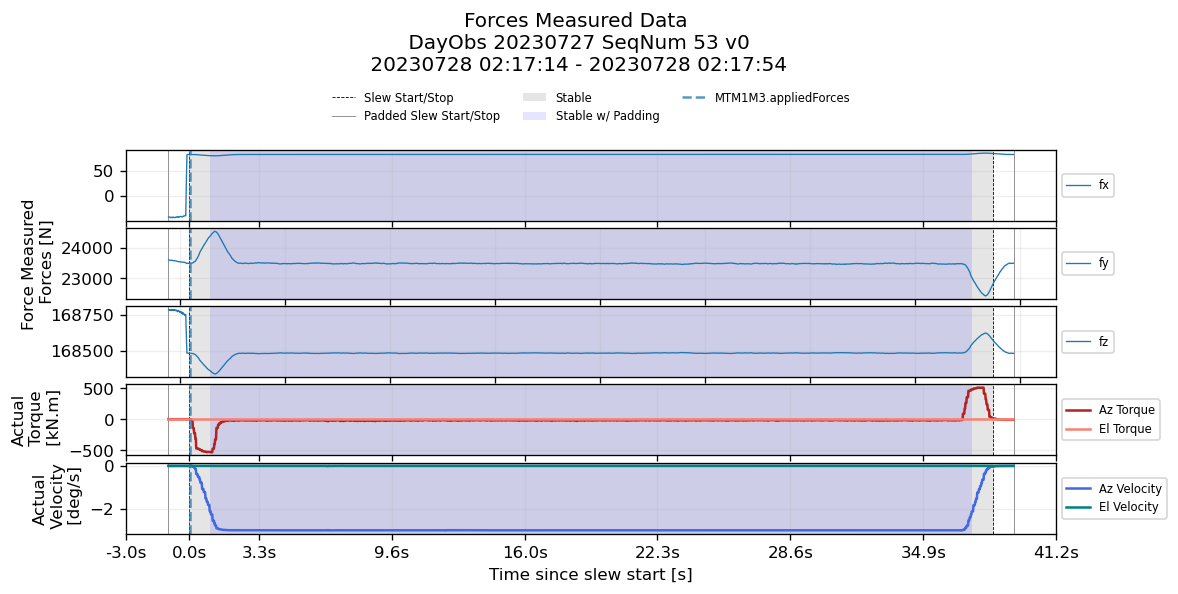

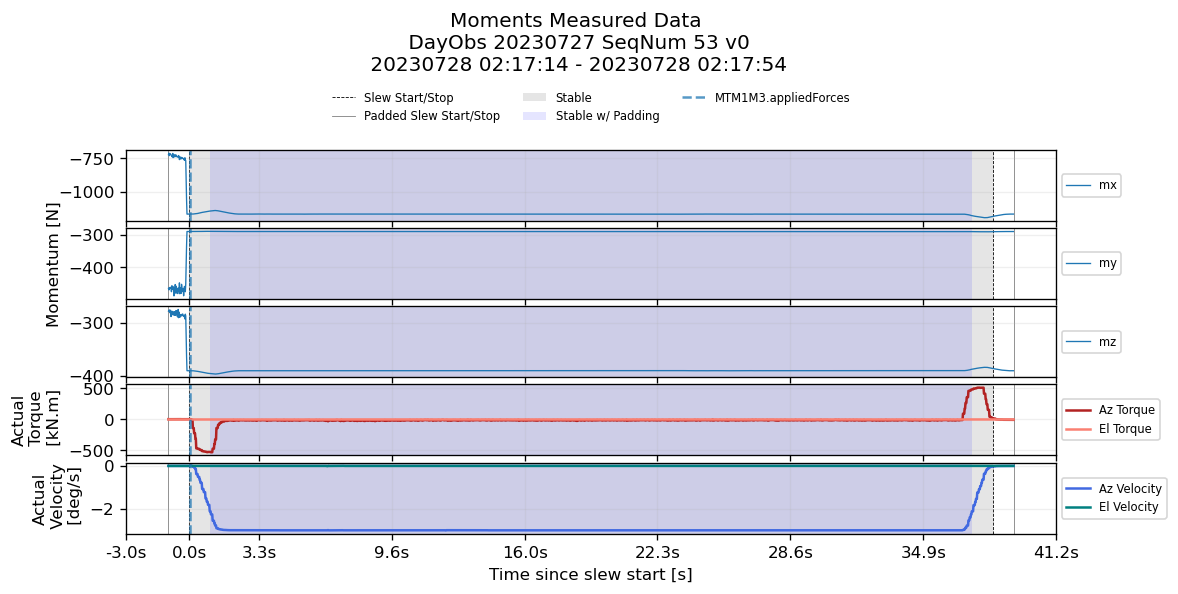

In [12]:
%matplotlib inline
data = analyze_m1m3_ics_slew_event(
    slew_data["20230727_ics_False_30"]["begin"],
    slew_data["20230727_ics_False_30"]["end"],
    event_maker,
    log,
    plot_path,
)


# data.stats

In [13]:
data.stats

day_obs                         20230727
seq_num                               53
slew_type                              2
end_reason                             0
time_duration                  38.226104
time_begin             1690510635.459096
time_end              1690510673.6852002
version                                0
az_start                        2.462449
az_end                         16.563506
az_extreme_vel                 -3.006999
az_extreme_torque            -532.383342
el_start                       -2.054348
el_end                         -1.757695
el_extreme_vel                 -0.011262
el_extreme_torque              -2.820801
ics_enabled                        False
az_diff                        14.101057
el_diff                         0.296653
measured_Min-fx                -42.71788
measured_Min-fy             22432.466797
measured_Min-fz               168334.875
measured_Min-mx             -1195.975952
measured_Min-my              -488.147888
measured_Min-mz 